# Análise de Emendas Parlamentares
## Versão final para apresentação

**Tema do trabalho:** relação entre distribuição de emendas parlamentares, desempenho eleitoral e indicadores sociais.

**Objeto analisado:** deputado Guilherme Cortez, com foco nos municípios do estado de São Paulo.

**Pergunta central:** as emendas parecem ter sido direcionadas mais para necessidade social ou para reduto eleitoral?

## 1. Hipóteses do trabalho

A análise foi organizada em três hipóteses:

- **H1. Justiça social:** municípios com menor IDH tenderiam a receber mais emendas.
- **H2. Reduto eleitoral absoluto:** municípios com mais votos no candidato tenderiam a receber mais emendas.
- **H3. Reduto eleitoral proporcional:** municípios onde o candidato foi mais forte em termos proporcionais tenderiam a receber mais emendas.

A lógica é simples: comparar a força de cada hipótese com base em dados municipais.

In [1]:
import os
import tempfile
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", tempfile.mkdtemp(prefix="mpl-config-"))

import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display, Markdown

import visualizacao as vis
from aquisicao import (
    CANDIDATO_ALVO,
    carregar_dados,
    preparar_votos,
    preparar_emendas,
    preparar_idh,
    preparar_populacao,
    juntar_dados,
)
from main import testar_hipoteses_simples

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

print(f"Pasta atual: {Path.cwd()}")
print(f"Candidato analisado: {CANDIDATO_ALVO}")

Matplotlib is building the font cache; this may take a moment.


Pasta atual: /Users/solanorigotti/Documents/TNA5373 - Extracao de dados/Códigos para projeto
Candidato analisado: GUILHERME CORTEZ


## 2. Bases utilizadas

Foram combinadas cinco fontes:

- votação do candidato por município;
- emendas parlamentares;
- IDH municipal;
- população municipal;
- tabela de municípios para padronização dos nomes.

O objetivo desta etapa é permitir que todas as bases possam ser comparadas usando o município como unidade de análise.

In [2]:
votos_raw, emendas_raw, idh_raw, populacao_raw, dtb = carregar_dados()

votos = preparar_votos(votos_raw, dtb)
emendas = preparar_emendas(emendas_raw, dtb)
idh = preparar_idh(idh_raw, dtb, uf_alvo="SP")
populacao = preparar_populacao(populacao_raw, dtb, uf_alvo="SP")

dados = juntar_dados(votos, emendas, idh, populacao, dtb)

dados["votos_per_capita"] = dados["votos_deputado"] / dados["populacao"].replace(0, np.nan)
dados["emenda_per_capita"] = dados["valor_emenda"] / dados["populacao"].replace(0, np.nan)

total_votos = dados["votos_deputado"].sum()
dados["market_share"] = dados["votos_deputado"] / total_votos if total_votos > 0 else np.nan

display(dados.head())


📂 Carregando arquivos...
✅ DTB carregado: 5572 municípios
✅ Votos: 645 municípios, 45,094 votos totais
   Exemplos: [{'nm_municipio': 'EUCLIDES DA CUNHA PAULISTA', 'votos_deputado': 0}, {'nm_municipio': 'ADAMANTINA', 'votos_deputado': 14}, {'nm_municipio': 'BOREBI', 'votos_deputado': 0}]
✅ Emendas do candidato: 162 total
   → 22 município específico, 80 múltiplos, 60 sem informação

   📍 Emendas com município específico em SP: 22
   ✅ Emendas com código IBGE: 22 de 22

   📋 Municípios com emendas:
      - BRAGANCA PAULISTA: R$ 500,000.00 (código: 3507605)
      - ARTUR NOGUEIRA: R$ 2,000,000.00 (código: 3503802)
      - ARTUR NOGUEIRA: R$ 1,000,000.00 (código: 3503802)
      - ARTUR NOGUEIRA: R$ 900,175.00 (código: 3503802)
      - GAVIAO PEIXOTO: R$ 121,217.00 (código: 3516853)
      - SALTO: R$ 850,000.00 (código: 3545209)
      - RIO CLARO: R$ 199,979.00 (código: 3543907)
      - ITAPEVA: R$ 500,000.00 (código: 3522406)
      - TAGUAI: R$ 199,869.00 (código: 3553005)
      - SAO MI

,nm_municipio,votos_deputado,idh,populacao,valor_emenda,votos_per_capita,emenda_per_capita,market_share
0,EUCLIDES DA CUNHA PAULISTA,0,0.704,9537.0,0.0,0.000000,0.0,0.000000
1,ADAMANTINA,14,0.790,33821.0,0.0,0.000414,0.0,0.000310
2,BOREBI,0,0.705,2321.0,0.0,0.000000,0.0,0.000000
3,ADOLFO,1,0.730,3548.0,0.0,0.000282,0.0,0.000022
4,TARUMA,2,0.753,13050.0,0.0,0.000153,0.0,0.000044


## 3. Leitura rápida da base final

Antes de interpretar o resultado, vale observar o panorama geral da base consolidada.

In [3]:
resumo = pd.DataFrame(
    {
        "Indicador": [
            "Municípios analisados",
            "Total de votos do candidato",
            "Municípios com IDH disponível",
            "Municípios com população disponível",
            "Municípios que receberam emendas",
            "Valor total das emendas",
        ],
        "Valor": [
            len(dados),
            float(dados["votos_deputado"].sum()),
            int(dados["idh"].notna().sum()),
            int(dados["populacao"].notna().sum()),
            int((dados["valor_emenda"] > 0).sum()),
            float(dados["valor_emenda"].sum()),
        ],
    }
)

display(resumo)

display(Markdown("### Municípios com mais votos no candidato"))
display(dados.nlargest(10, "votos_deputado")[["nm_municipio", "votos_deputado"]])

display(Markdown("### Municípios que receberam emendas"))
display(dados[dados["valor_emenda"] > 0].sort_values("valor_emenda", ascending=False)[["nm_municipio", "valor_emenda"]])

,Indicador,Valor
0,Municípios analisados,645.00
1,Total de votos do candidato,45094.00
2,Municípios com IDH disponível,634.00
3,Municípios com população disponível,633.00
4,Municípios que receberam emendas,17.00
5,Valor total das emendas,11770066.24


### Municípios com mais votos no candidato

,nm_municipio,votos_deputado
575,SAO PAULO,12848
234,FRANCA,10535
506,RIBEIRAO PRETO,982
167,CAMPINAS,840
260,GUARULHOS,746
559,SAO BERNARDO DO CAMPO,576
416,OSASCO,560
594,SOROCABA,469
550,SANTO ANDRE,433
571,SAO JOSE DOS CAMPOS,423


### Municípios que receberam emendas

,nm_municipio,valor_emenda
75,ARTUR NOGUEIRA,3900175.00
600,TABOAO DA SERRA,2542000.00
296,ITAPEVA,999246.20
524,SALTO,850000.00
304,ITARARE,596100.04
148,BRAGANCA PAULISTA,500000.00
574,SAO MIGUEL ARCANJO,500000.00
357,MAIRIPORA,500000.00
422,PALESTINA,250000.00
511,RIO CLARO,199979.00


## 4. Evidências iniciais

As correlações abaixo servem como leitura preliminar.

Elas ajudam a identificar se existe associação entre votos, emendas, população e IDH.

In [4]:
correlacoes = []

def registrar_corr(x, y, nome):
    base = dados[[x, y]].dropna()
    if len(base) >= 2:
        correlacoes.append({
            "Relação": nome,
            "Correlação": base.corr().iloc[0, 1],
            "N": len(base),
        })

registrar_corr("votos_deputado", "populacao", "Votos x População")
registrar_corr("votos_deputado", "idh", "Votos x IDH")
registrar_corr("valor_emenda", "idh", "Emendas x IDH")
registrar_corr("market_share", "valor_emenda", "Participação eleitoral x Emendas")
registrar_corr("votos_per_capita", "emenda_per_capita", "Votos per capita x Emendas per capita")

display(pd.DataFrame(correlacoes))

,Relação,Correlação,N
0,Votos x População,0.787454,633
1,Votos x IDH,0.144832,634
2,Emendas x IDH,0.035134,634
3,Participação eleitoral x Emendas,-0.000535,645
4,Votos per capita x Emendas per capita,-0.006795,633


## 5. Teste das hipóteses

Agora a base é dividida em dois grupos:

- municípios que receberam emendas;
- municípios que não receberam emendas.

A comparação desses grupos permite verificar qual hipótese recebe mais apoio dos dados.

In [5]:
com_emendas, sem_emendas = testar_hipoteses_simples(dados)


🧪 TESTE DE HIPÓTESES - DADOS DISPONÍVEIS

📊 Comparação: 17 cidades com emendas vs 628 sem emendas

🔹 H1: JUSTIÇA SOCIAL - Emendas para municípios de BAIXO IDH
--------------------------------------------------
   IDH médio (com emendas): 0.740
   IDH médio (sem emendas): 0.739
   Diferença: 0.000
   ❌ Contra H1: Cidades com emendas têm IDH MAIOR ou igual

🔹 H2: REDUTO ELEITORAL - Emendas onde tem MAIS VOTOS
--------------------------------------------------
   Votos médios (com emendas): 41.5
   Votos médios (sem emendas): 70.7
   Diferença: -29.2 votos
   ❌ Contra H2: Cidades com emendas têm MENOS votos

🔹 H3: REDUTO ELEITORAL (per capita) - Emendas onde tem MAIS VOTOS/HABITANTE
--------------------------------------------------
   Votos/hab (com emendas): 0.000600
   Votos/hab (sem emendas): 0.000841
   Diferença: -0.000241
   ❌ Contra H3: Cidades com emendas têm MENOS votos per capita

🔍 ANÁLISE QUALITATIVA - Top 5 municípios com emendas
--------------------------------------------

## 6. Visualização dos resultados

Os gráficos ajudam a transformar a comparação numérica em evidência visual.

Na apresentação, estes são os gráficos mais importantes para comentar.

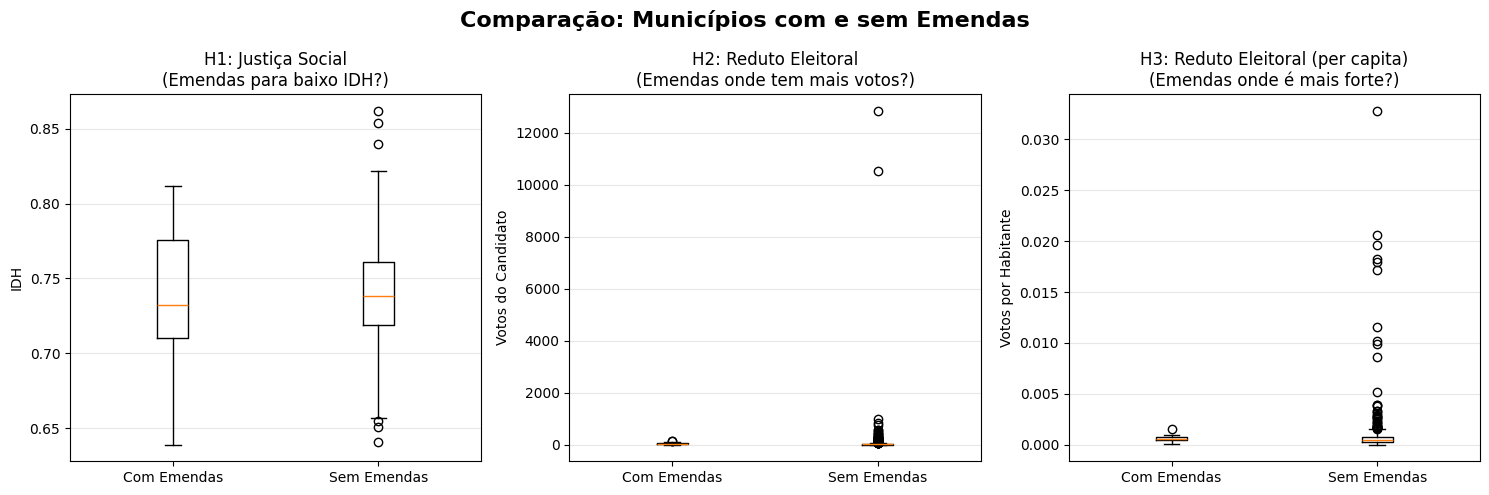

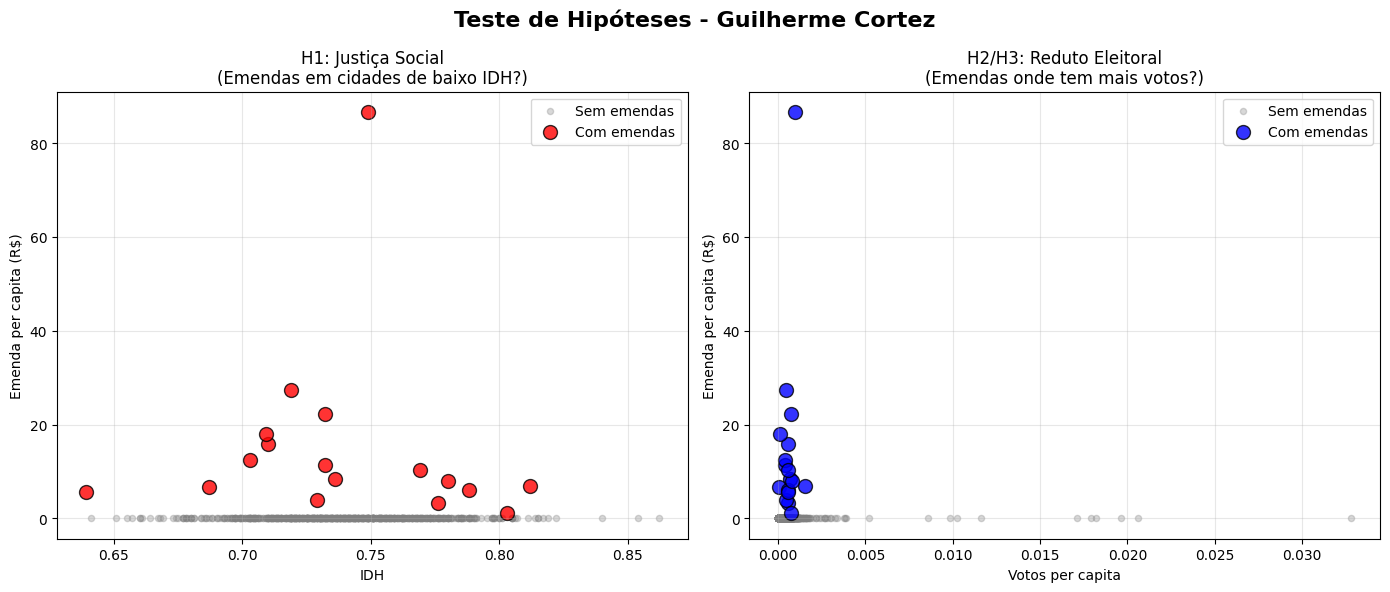

In [6]:
vis.comparar_grupos_simples(com_emendas, sem_emendas)

if "votos_per_capita" in dados.columns and "emenda_per_capita" in dados.columns:
    vis.scatter_hipoteses(dados)
else:
    print("Os gráficos per capita não puderam ser exibidos porque a variável de população não ficou disponível na base final.")